# Modelo: TextCF

- Embeddings: `all-MiniLM-L6-v2` (384 dimensiones)

In [15]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
import sys
sys.path.append("..")
from src.evaluation import temporal_train_test_split, evaluate_model
from src.text_features import TextFeatureExtractor

MODEL_NAME = "textcf"
RESULTS_DIR = f"../results/{MODEL_NAME}"
N_FACTORS = 50


## Modelo

In [16]:
class TextCF:
    """
    Hibrido: combina la prediccion de SVD (filtrado colaborativo) con
    la similitud coseno entre el perfil textual del usuario y los
    embeddings de los Items.

    score(u,i) = alpha * norm(SVD_score(u,i)) + (1-alpha) * cosine(user_text_profile, text_emb_i)

    El perfil del usuario se construye como el promedio de los embeddings
    de los Item que valoran con rating >= like_threshold en train.
    """
    def __init__(self, text_embeddings, svd_model, alpha=0.5, like_threshold=3.0):
        self.alpha = alpha
        self._threshold = like_threshold
        self._svd = svd_model
        self._ids = list(text_embeddings.keys())
        self._matrix = np.stack([text_embeddings[b] for b in self._ids])
        self._id_to_idx = {bid: i for i, bid in enumerate(self._ids)}

    def _user_profile(self, user_id, train_reviews):
        liked = train_reviews[
            (train_reviews['user_id'] == user_id) &
            (train_reviews['stars'] >= self._threshold)
        ]['business_id'].tolist()
        liked = [b for b in liked if b in self._id_to_idx]
        if not liked:
            liked = train_reviews[train_reviews['user_id'] == user_id]['business_id'].tolist()
            liked = [b for b in liked if b in self._id_to_idx]
        if not liked:
            return None
        return np.mean([self._matrix[self._id_to_idx[b]] for b in liked], axis=0)

    def _svd_scores_normalized(self, user_id):
        svd = self._svd
        if user_id not in svd['user_index']:
            return {}
        u_idx = svd['user_index'][user_id]
        raw = svd['predicted'][u_idx]
        vmin, vmax = raw.min(), raw.max()
        denom = vmax - vmin if vmax > vmin else 1.0
        idx_to_bid = {v: k for k, v in svd['item_index'].items()}
        return {idx_to_bid[j]: float((raw[j] - vmin) / denom)
                for j in range(len(raw)) if j in idx_to_bid}

    def recommend(self, user_id, train_reviews, top_k=10):
        seen = set(train_reviews[train_reviews['user_id'] == user_id]['business_id'])
        cf_scores = self._svd_scores_normalized(user_id)
        profile = self._user_profile(user_id, train_reviews)
        if profile is not None:
            sims = cosine_similarity(profile.reshape(1, -1), self._matrix)[0]
            text_scores = {bid: float(sims[i]) for i, bid in enumerate(self._ids)}
        else:
            text_scores = {}
        final = {}
        for bid in self._ids:
            if bid in seen:
                continue
            final[bid] = self.alpha * cf_scores.get(bid, 0.0) + (1 - self.alpha) * text_scores.get(bid, 0.0)
        return sorted(final, key=final.get, reverse=True)[:top_k]

## Datos y embeddings

In [17]:
reviews = pd.read_csv('../data/processed/reviews.csv', parse_dates=['date'])
train_reviews, test_reviews = temporal_train_test_split(reviews, test_fraction=0.2)
text_embeddings = TextFeatureExtractor.load('text_embeddings.npz')
print(f'Train: {len(train_reviews)} | Test: {len(test_reviews)}')
print(f'Text embeddings: {len(text_embeddings)} items, dim={next(iter(text_embeddings.values())).shape[0]}')

Train: 61870 reviews | Test: 13114 reviews
Train: 61870 | Test: 13114
Text embeddings: 1151 items, dim=384


## Entrenar SVD base

In [18]:
users = train_reviews["user_id"].unique()
items = train_reviews["business_id"].unique()
user_idx = {u: i for i, u in enumerate(users)}
item_idx = {b: i for i, b in enumerate(items)}

rows = train_reviews["user_id"].map(user_idx)
cols = train_reviews["business_id"].map(item_idx)
vals = train_reviews["stars"].astype(float)
matrix = csr_matrix((vals, (rows, cols)), shape=(len(users), len(items)))

svd = TruncatedSVD(n_components=N_FACTORS, random_state=42)
U_sigma = svd.fit_transform(matrix)
Vt = svd.components_
predicted = U_sigma @ Vt

svd_model = {"predicted": predicted, "user_index": user_idx, "item_index": item_idx}
print(f"SVD: {len(users)} users x {len(items)} items, k={N_FACTORS}")
print(f"Explained variance ratio: {svd.explained_variance_ratio_.sum():.3f}")


SVD: 6528 users x 582 items, k=50
Explained variance ratio: 0.394


## Evaluacion completa

In [19]:
# ILD necesita un espacio de features comun a todos los modelos (SBERT)
from src.text_features import TextFeatureExtractor
if 'text_embeddings' not in globals():
    text_embeddings = TextFeatureExtractor.load('text_embeddings.npz')

model = TextCF(text_embeddings, svd_model, alpha=0.5, like_threshold=4.0)
metrics = evaluate_model(
    lambda uid, top_k: model.recommend(uid, train_reviews, top_k),
    test_reviews, train_reviews, k_values=[5, 10, 20],
    item_features=text_embeddings,
)
print(f'TextCF (alpha=0.5, like_threshold=4.0):')
print(metrics.round(4))

TextCF (alpha=0.5, like_threshold=4.0):
    precision  recall    ndcg  novelty  hit_rate  coverage     ild
K                                                                 
5      0.0142  0.0358  0.0276   5.3049    0.0671    0.5172  0.3935
10     0.0120  0.0577  0.0355   5.5312    0.1098    0.5808  0.3947
20     0.0097  0.0941  0.0460   5.8092    0.1690    0.6014  0.3979


## Guardar resultados

In [20]:
os.makedirs(RESULTS_DIR, exist_ok=True)
metrics.to_csv(f'{RESULTS_DIR}/metrics.csv')
with open(f'{RESULTS_DIR}/config.json', 'w') as f:
    json.dump({'model': 'TextCF', 'alpha': 0.5, 'n_factors': N_FACTORS,
               'sbert_model': 'all-MiniLM-L6-v2', 'like_threshold': 4.0}, f, indent=2)
print(f'Saved -> results/{MODEL_NAME}/')

Saved -> results/textcf/


## Ejemplos de recomendaciones

5 usuarios fijos (seed=42, los mismos en todos los notebooks): historial + recomendaciones con texto, restaurante e imagen.

Usuarios de ejemplo: ['lo9Z0oVT-kz2DJwPE3X0Og', 'R53y0qIWqJZxnbyWNDbrMg', 'dzAZWHtJ52JI8J4zB2mkow', '4tqv48yYK6Jk5aZsncDC-g', 'QlueMJlhDGDGxR9arq_xSg']

Usuario lo9Z0oVT-kz2DJwPE3X0Og  |  5 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] City Diner - "Finally a new diner in the city MUCH NEEDED for industry people & socialites that have late night schedules . Very Clean and mangled very well"
  [5*] National Mechanics - "Place is great but the evening server Jennifer makes it amazing. Most personable & welcoming server I've ever met. Make sure you guys keep her around P.S. the l..."
  [4*] Fare - "Good food pretty good variety menu . My favorite thing about this place is their outdoor courtyard which is very nice at night w/ the heated lamps & fireplace i..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Prohibition Taproom (Philadelphia) - 4.0* - Americ

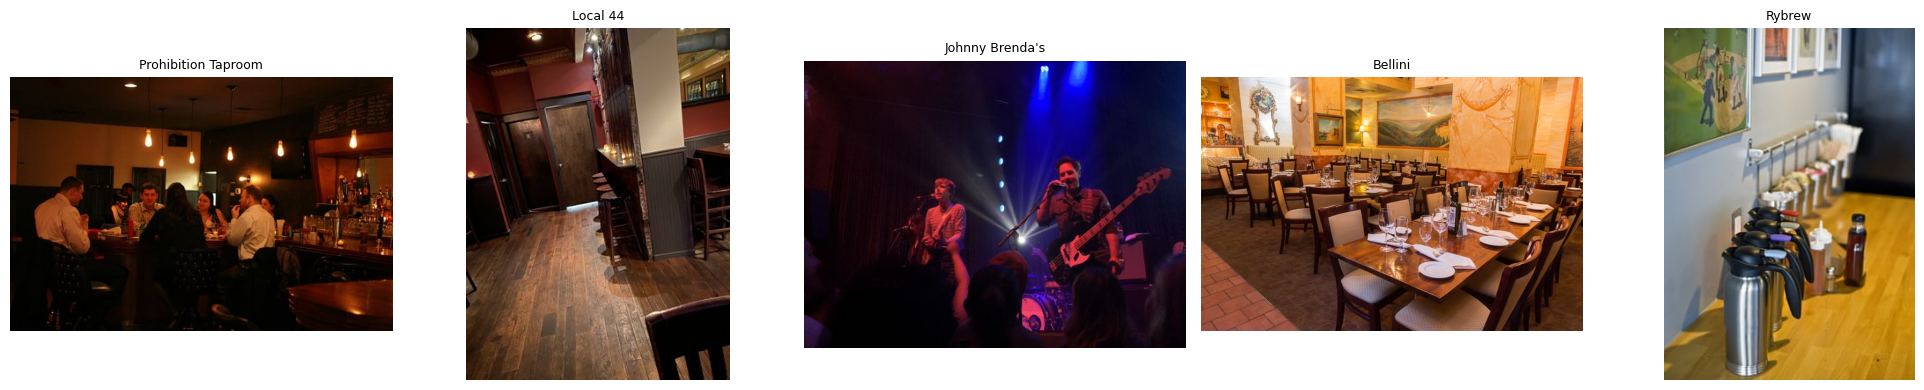


Usuario R53y0qIWqJZxnbyWNDbrMg  |  9 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] Han Dynasty - "First, I must rave about the superb service we received by our waitress. We came here last Sunday after making reservations for 15 for my boyfriend's surprise b..."
  [4*] Crazy Sushi - "One item is enough to make me write this review:  Salmon Pizza! Get it! Pictures & a more thorough review to come when I return - which shall be soon."
  [4*] Moshulu - "This review is for their restaurant week menu  Food: 3.5/5  Apps: california shrimp crunch roll & crispy calamari/artichoke hearts Their appetizers were amazing..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Sabrina's Café (Philadelphia) - 4.0* - Breakfast & Brunch, Restaurants, Vegetarian, American (New),...
  2. Bleu Sushi (Philadelphia) - 4.5* - Sushi Bars, Japanese, Restaurants, Asian Fusion, Tapas

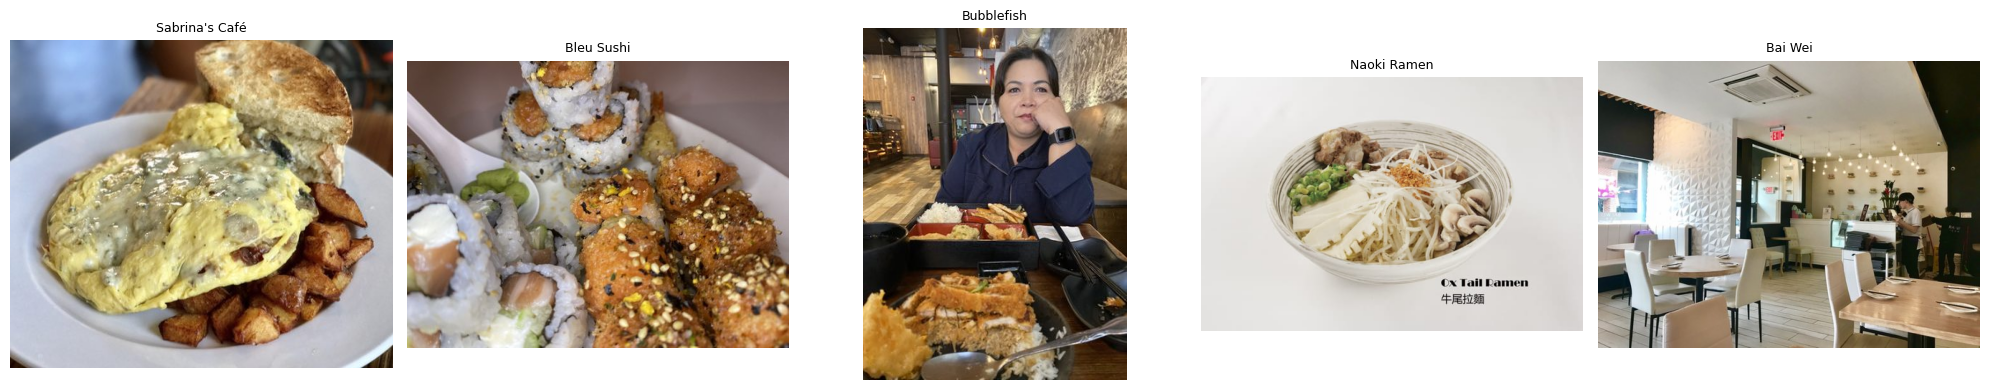


Usuario dzAZWHtJ52JI8J4zB2mkow  |  5 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] Dalessandro’s Steaks & Hoagies - "And down simply the best cheesesteak in Philadelphia and make sure you go a little early because it's always packed door-to-door for lunch"
  [3*] Jim's South St - "Very tasty but they need to add more meat for 9$ cheesesteak  Their are a few better out there Delsandros and sonnys right up the street  Fries are not availabl..."
  [1*] John's Roast Pork - "Simply the most OVER RATED pork sandwich I've ever had...  Their cheese steaks are the highlight of this place!!!! Their prices are about par for the course"
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Ishkabibble's (Philadelphia) - 4.0* - Restaurants, Seafood, Cheesesteaks, Burgers, Pizza, Sandwich...
  2. Sonny's Famous Steaks (Philadelphia) - 4.0* - Cheesesteaks, Comfort Food, Res

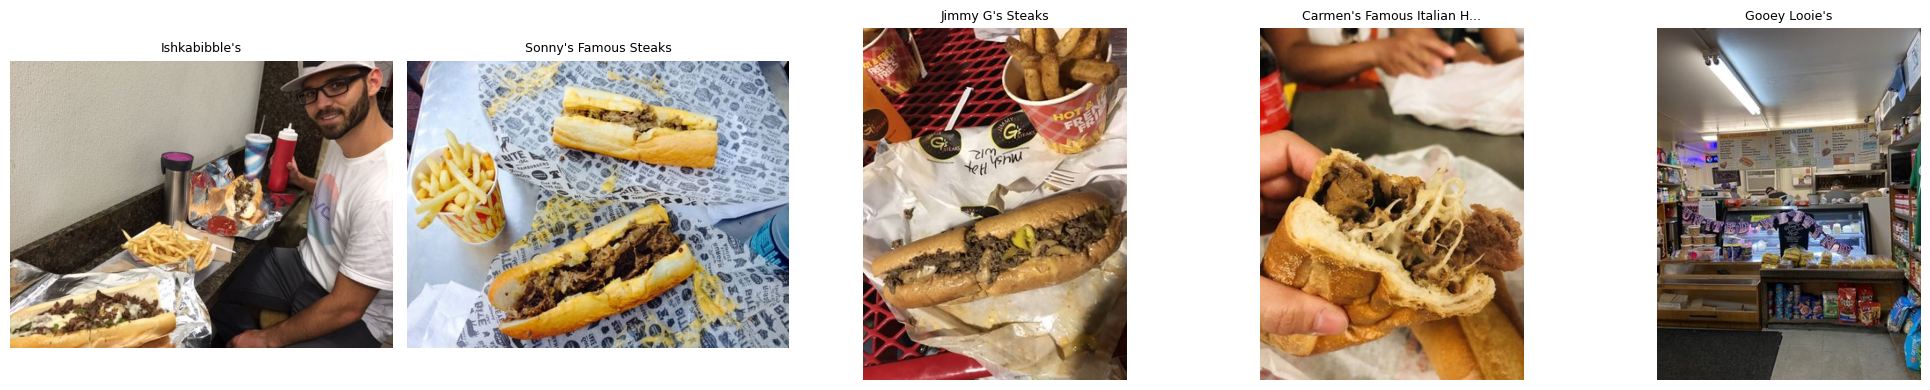


Usuario 4tqv48yYK6Jk5aZsncDC-g  |  20 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] Tinto - "This place is one of those that you might not want to miss it if you live in Philadelphia. I went there last November and had an amazing time. The atmosphere in..."
  [5*] P S & Co - "Thumbs up to the owner for her brilliant ideas. Pure Sweet is a place that I truly feel I'm not waisting my money. I pursue a very restricted diet and the fact ..."
  [5*] The Farm and Fisherman - "What can I say about this place? It's a gem. I had dinner here couple of months ago leaving me with the best impressions. Service is outstanding. The server pre..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Little Nonna's (Philadelphia) - 4.0* - Restaurants, Italian
  2. R2L (Philadelphia) - 3.5* - American (New), Lounges, Nightlife, Cocktail Bars, Bars, Res...
  3. IndeBlue Modern

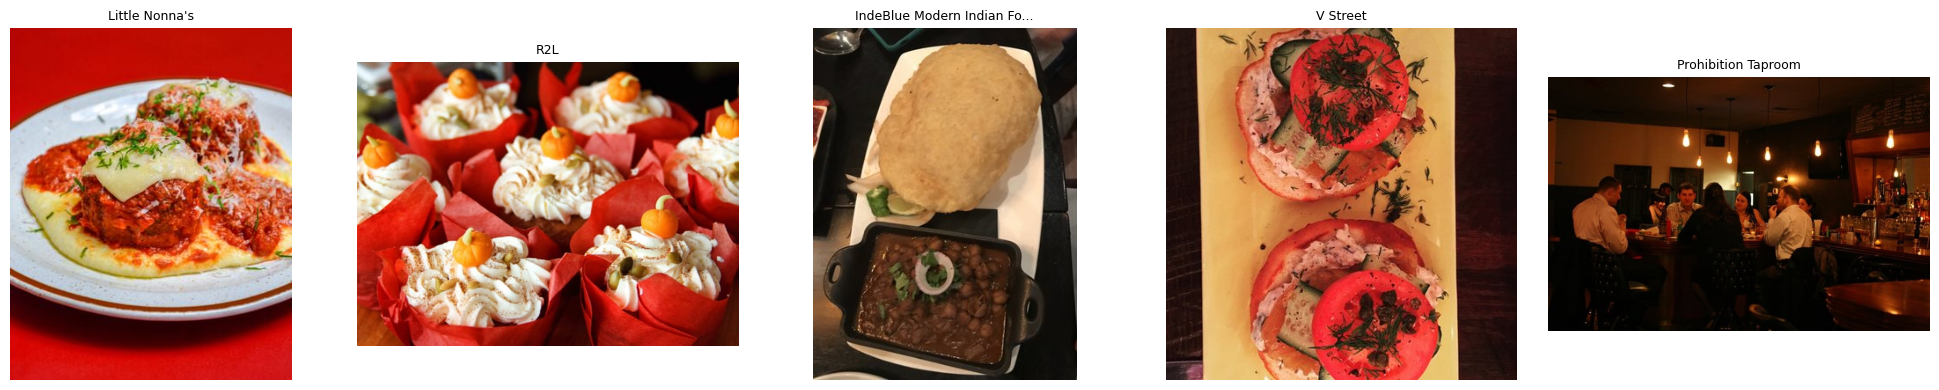


Usuario QlueMJlhDGDGxR9arq_xSg  |  4 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] Pizzeria Vetri - "The arugula salad with pesto was hands down the best salad I've had in my life. And if you're even considering the Nutella dessert pie, get it. You won't be dis..."
  [5*] Dante & Luigi's - "Dante & Luigi's was the perfect place for my boyfriend and I to take his mom when she visited town. The atmosphere was great - felt just like you were in someon..."
  [5*] Kanella South - "The portions are large, the food is authentic, the new location is gorgeous, and the whole experience is amazing. I absolutely adore Kenella's!"
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Luke's Lobster Rittenhouse (Philadelphia) - 4.5* - Sandwiches, Seafood, Restaurants
  2. Gran Caffe L'Aquila (Philadelphia) - 4.5* - Restaurants, Gelato, Coffee & Tea, Food, Italian, Bakeries

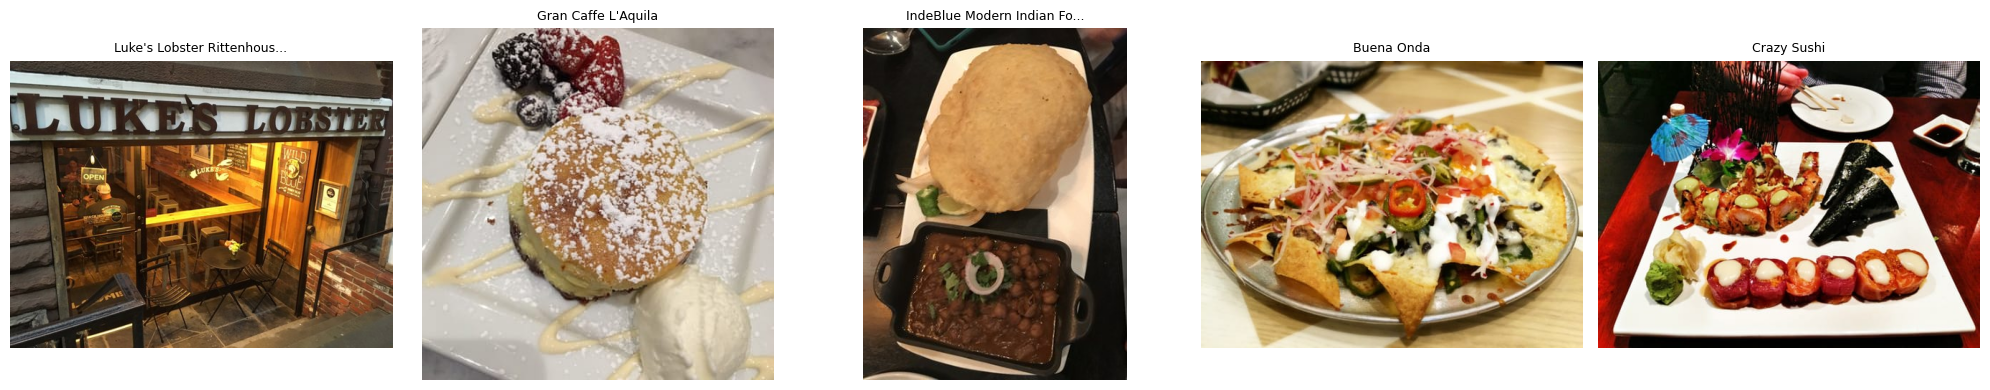

In [21]:
# 5 usuarios fijos por seed (mismos en todos los notebooks)
import pandas as pd
from src.examples import pick_sample_users, show_user_recommendations

restaurants_meta = pd.read_csv('../data/processed/restaurants.csv')
try:
    photos_meta = pd.read_csv('../data/processed/photos.csv')
except FileNotFoundError:
    photos_meta = None

sample_users = pick_sample_users(train_reviews, n=5, seed=42)
print('Usuarios de ejemplo:', sample_users)

for uid in sample_users:
    show_user_recommendations(
        uid,
        lambda u, top_k: model.recommend(u, train_reviews, top_k),
        train_reviews, restaurants_meta, photos=photos_meta,
        top_k=5, show_images=True,
    )